# Bayesian alternative to the two-sample t-test (BEST), implemented in NumPyro

*Hugo Storm, Sep 2026*

*Code generation supported by Claude Code Opus 5.5*

Based on Kruschke, J. K. (2013). *Bayesian estimation supersedes the t test.* Journal of Experimental Psychology: General, 142(2), 573.

Instead of a p-value for $H_0: \mu_A = \mu_B$, we get full posteriors for the difference in means, the difference in standard deviations and the effect size. Decisions use the 95% HDI together with a ROPE (region of practical equivalence) around zero.

**Model** (fit on standardized data so the priors are scale-free):

$$
\begin{aligned}
\mu_g &\sim \text{Normal}(0, 10), \quad g \in \{A, B\} \\
\sigma_g &\sim \text{HalfNormal}(10) \quad \text{(separate spreads)} \\
\nu - 1 &\sim \text{Exponential}(1/29) \quad \text{(shared normality parameter)} \\
y_{gi} &\sim \text{StudentT}(\nu, \mu_g, \sigma_g)
\end{aligned}
$$

In [1]:
import numpy as np
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import arviz as az
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, Predictive
from scipy import stats

rng = np.random.default_rng(123)

## Synthetic data

Two normal groups with a true mean difference of 1.0.

In [2]:
true_mu_a, true_mu_b = 10.0, 11.0
true_sd_a, true_sd_b = 2.0, 2.5
n_a, n_b = 80, 70

group_a = rng.normal(true_mu_a, true_sd_a, size=n_a)
group_b = rng.normal(true_mu_b, true_sd_b, size=n_b)

print(f"Group A: n={n_a}, mean={group_a.mean():.3f}, sd={group_a.std(ddof=1):.3f}")
print(f"Group B: n={n_b}, mean={group_b.mean():.3f}, sd={group_b.std(ddof=1):.3f}")

Group A: n=80, mean=10.161, sd=1.839
Group B: n=70, mean=11.446, sd=2.328


# Estimate model

Prepare data for the model: group labels, pooled mean/sd, and standardized values.

In [3]:
def prepare(a, b):
    y = np.concatenate([a, b])
    group = np.concatenate([np.zeros(a.size, dtype=int), np.ones(b.size, dtype=int)])
    loc, scale = y.mean(), y.std(ddof=1)
    return jnp.asarray(group), float(loc), float(scale), jnp.asarray((y - loc) / scale)


group, loc, scale, y_std = prepare(group_a, group_b)

Model. Data is standardized with the pooled mean/sd; the derived quantities are reported back on the original scale via `loc` and `scale`.

In [4]:
def best_model(group, loc, scale, y=None):
    # Prior on the two different means
    mu = numpyro.sample("mu_std", dist.Normal(0.0, 10.0).expand([2]))
    # Prior on the two different standard deviations
    sigma = numpyro.sample("sigma_std", dist.HalfNormal(10.0).expand([2]))
    # Prior on the shared normality parameter (nu) of the Student's t-distribution.
    # As proposed in the Kruschke 2013 paper
    nu_minus_one = numpyro.sample("nu_minus_one", dist.Exponential(1.0 / 29.0))
    nu = numpyro.deterministic("nu", nu_minus_one + 1.0)

    # Back-transform to the original data scale.
    mu_orig = numpyro.deterministic("mu", loc + scale * mu)
    sigma_orig = numpyro.deterministic("sigma", scale * sigma)
    numpyro.deterministic("diff_means", mu_orig[0] - mu_orig[1])
    numpyro.deterministic("diff_sds", sigma_orig[0] - sigma_orig[1])
    numpyro.deterministic(
        "effect_size",
        (mu[0] - mu[1]) / jnp.sqrt((sigma[0] ** 2 + sigma[1] ** 2) / 2.0),
    )

    with numpyro.plate("obs", group.shape[0]):
        numpyro.sample("y_std", dist.StudentT(nu, mu[group], sigma[group]), obs=y)

Fit with NUTS.

In [5]:
def fit(group, loc, scale, y_std, key, num_warmup=500, num_samples=500, num_chains=4):
    mcmc = MCMC(
        NUTS(best_model),
        num_warmup=num_warmup,
        num_samples=num_samples,
        num_chains=num_chains,
        chain_method="vectorized",  # all chains in one batch on a single device
        progress_bar=True,
    )
    mcmc.run(key, group, loc, scale, y=y_std)
    return mcmc


mcmc = fit(group, loc, scale, y_std, jr.key(1))
samples = mcmc.get_samples()

sample: 100%|██████████| 1000/1000 [00:07<00:00, 130.02it/s]


Diagnostics

In [ ]:
idata = az.from_numpyro(mcmc)
print(az.summary(idata, var_names=["mu", "sigma", "nu", "diff_means", "diff_sds", "effect_size"]))

# Decision/test based on estimated model

Decision summary: HDI + ROPE on the effect size, and direct probabilities. The researcher specifies a region of practical equivalence (ROPE) around the null value, which encloses those values of the parameter that are deemed to be negligibly different from the null value for practical purposes.

In [6]:
ROPE = (-0.1, 0.1)  # |effect size| < 0.1 counts as "practically no difference"
HDI_PROB = 0.95


def hdi(x, prob=HDI_PROB):
    return np.asarray(az.hdi(np.asarray(x), prob=prob))


def summarize(samples, rope=ROPE):
    diff = np.asarray(samples["diff_means"])
    d = np.asarray(samples["effect_size"])
    d_hdi = hdi(d)
    if d_hdi[0] > rope[1] or d_hdi[1] < rope[0]:
        decision = "credible difference (HDI entirely outside ROPE)"
    elif d_hdi[0] >= rope[0] and d_hdi[1] <= rope[1]:
        decision = "practically equivalent (HDI entirely inside ROPE)"
    else:
        decision = "undecided (HDI overlaps ROPE)"
    return {
        "diff_mean": diff.mean(),
        "diff_hdi": hdi(diff),
        "p_a_less_b": (diff < 0).mean(),
        "d_mean": d.mean(),
        "d_hdi": d_hdi,
        "p_in_rope": ((d > rope[0]) & (d < rope[1])).mean(),
        "decision": decision,
    }


def print_summary(s):
    print(f"  mean diff (A - B) = {s['diff_mean']:.3f}, "
          f"95% HDI = [{s['diff_hdi'][0]:.3f}, {s['diff_hdi'][1]:.3f}]")
    print(f"  P(mu_A < mu_B | data) = {s['p_a_less_b']:.4f}")
    print(f"  effect size = {s['d_mean']:.3f}, "
          f"95% HDI = [{s['d_hdi'][0]:.3f}, {s['d_hdi'][1]:.3f}]")
    print(f"  P(effect size in ROPE {ROPE}) = {s['p_in_rope']:.4f}")
    print(f"  Decision: {s['decision']}")


result = summarize(samples)
print("\nBEST")
print_summary(result)


BEST
  mean diff (A - B) = -1.294, 95% HDI = [-1.988, -0.626]
  P(mu_A < mu_B | data) = 0.9990
  effect size = -0.632, 95% HDI = [-0.983, -0.288]
  P(effect size in ROPE (-0.1, 0.1)) = 0.0025
  Decision: credible difference (HDI entirely outside ROPE)


Posterior plots for the quantities of interest.

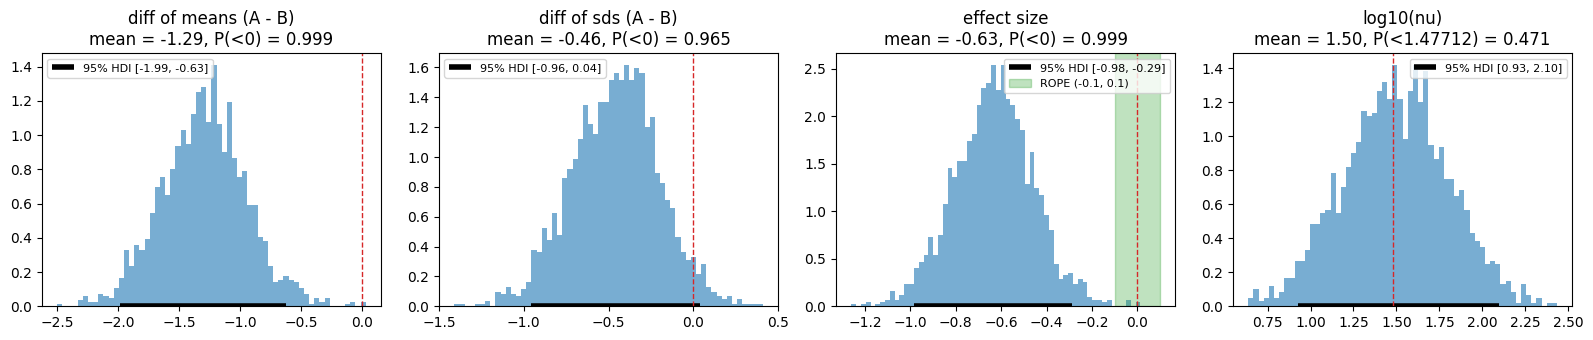

In [7]:
def plot_posterior(ax, x, title, ref=0.0, rope=None):
    x = np.asarray(x)
    lo, hi = hdi(x)
    ax.hist(x, bins=60, density=True, color="C0", alpha=0.6)
    ax.hlines(0, lo, hi, color="k", lw=4, label=f"95% HDI [{lo:.2f}, {hi:.2f}]")
    if rope is not None:
        ax.axvspan(*rope, color="C2", alpha=0.3, label=f"ROPE {rope}")
    ax.axvline(ref, color="C3", ls="--", lw=1)
    ax.set_title(f"{title}\nmean = {x.mean():.2f}, P(<{ref:g}) = {(x < ref).mean():.3f}")
    ax.legend(fontsize=8)


fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
plot_posterior(axes[0], samples["diff_means"], "diff of means (A - B)")
plot_posterior(axes[1], samples["diff_sds"], "diff of sds (A - B)")
plot_posterior(axes[2], samples["effect_size"], "effect size", rope=ROPE)
plot_posterior(axes[3], np.log10(np.asarray(samples["nu"])), "log10(nu)", ref=np.log10(30))
plt.tight_layout()
plt.show()

Comparison with the frequentist Welch t-test on the same data.

In [8]:
def compare(a, b, samples, label):
    welch = stats.ttest_ind(a, b, equal_var=False)
    ci = welch.confidence_interval(confidence_level=HDI_PROB)
    s = summarize(samples)
    print(f"\n=== {label} (n_A={a.size}, n_B={b.size}) ===")
    print(f"Welch  : p = {welch.pvalue:.4f}, 95% CI = [{ci.low:.3f}, {ci.high:.3f}]")
    print("BEST   :")
    print_summary(s)


compare(group_a, group_b, samples, "Main sample")


=== Main sample (n_A=80, n_B=70) ===
Welch  : p = 0.0003, 95% CI = [-1.970, -0.601]
BEST   :
  mean diff (A - B) = -1.294, 95% HDI = [-1.988, -0.626]
  P(mu_A < mu_B | data) = 0.9990
  effect size = -0.632, 95% HDI = [-0.983, -0.288]
  P(effect size in ROPE (-0.1, 0.1)) = 0.0025
  Decision: credible difference (HDI entirely outside ROPE)


Comparison with the frequentist Welch t-test on a smaller sample (n = 40/35) where Welch's test failed to reject H0.

In [9]:
small_rng = np.random.default_rng(123)
small_a = small_rng.normal(true_mu_a, true_sd_a, size=40)
small_b = small_rng.normal(true_mu_b, true_sd_b, size=35)
small_samples = fit(*prepare(small_a, small_b), jr.key(3)).get_samples()
compare(small_a, small_b, small_samples, "Small sample")

sample: 100%|██████████| 1000/1000 [00:07<00:00, 133.96it/s]


=== Small sample (n_A=40, n_B=35) ===
Welch  : p = 0.1777, 95% CI = [-1.649, 0.311]
BEST   :
  mean diff (A - B) = -0.560, 95% HDI = [-1.545, 0.529]
  P(mu_A < mu_B | data) = 0.8615
  effect size = -0.264, 95% HDI = [-0.739, 0.224]
  P(effect size in ROPE (-0.1, 0.1)) = 0.1925
  Decision: undecided (HDI overlaps ROPE)
